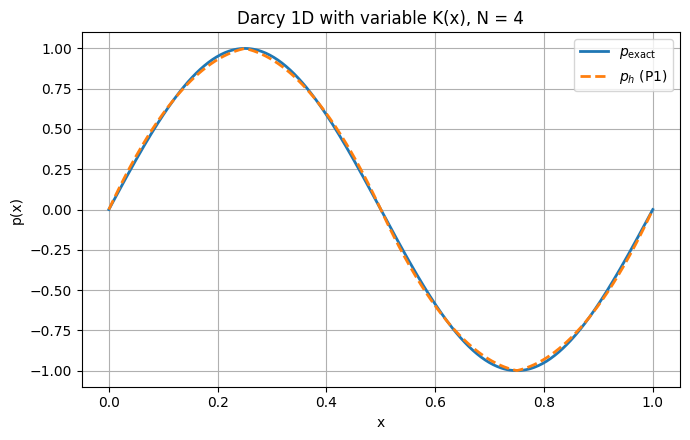

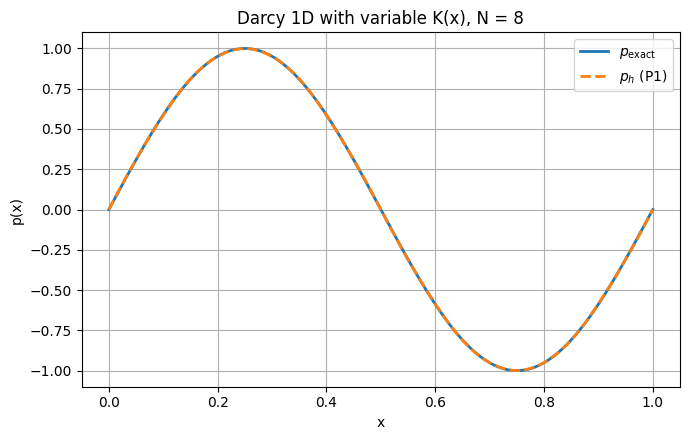

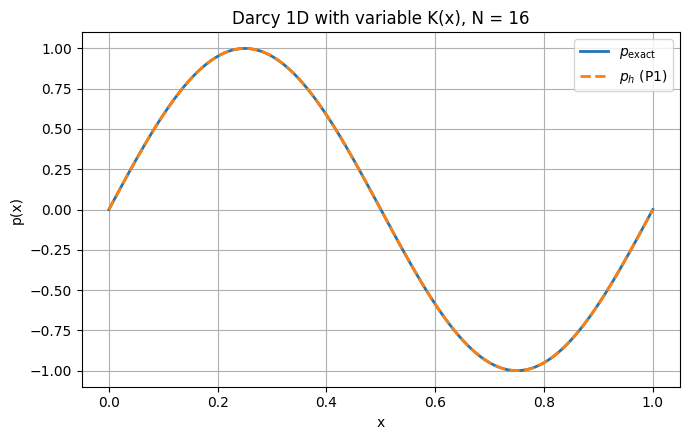

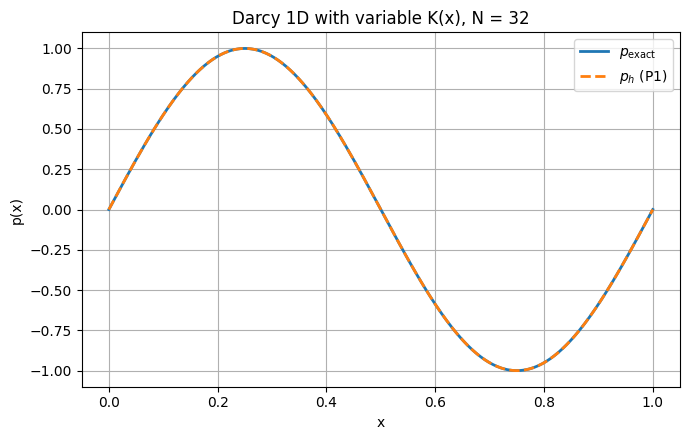

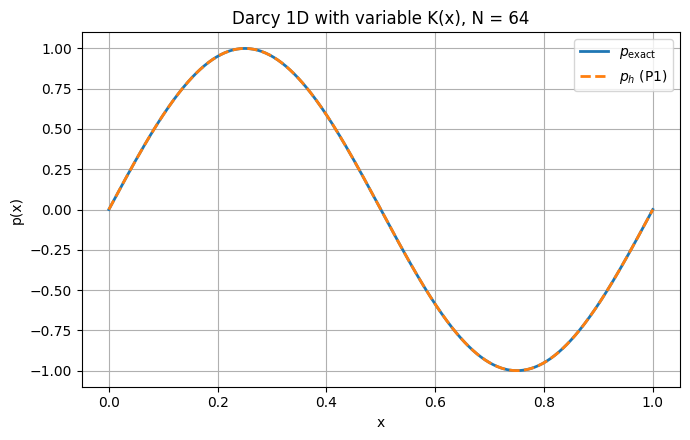

       N            h         ||e||_L2     rate(L2)           |e|_H1     rate(H1)
----------------------------------------------------------------------------------
       4 2.500000e-01   1.51998723e-02          ---   3.94533914e-01          ---
       8 1.250000e-01   1.95225404e-03     2.960847   1.01250195e-01     1.962225
      16 6.250000e-02   2.45692666e-04     2.990214   2.54784575e-02     1.990575
      32 3.125000e-02   3.07636886e-05     2.997554   6.38002102e-03     1.997645
      64 1.562500e-02   3.84709092e-06     2.999389   1.59565626e-03     1.999411


In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
from math import log
import matplotlib.pyplot as plt
import math

from dolfinx import fem, mesh, geometry
from dolfinx.fem.petsc import LinearProblem
import ufl


def exact_p_array(x):
    # x has shape (gdim, num_points)
    return np.sin(2 * np.pi * x[0])


def solve_darcy_1d(ncells: int):
    """
    Solve
        -(K(x) p')' = f  on (0,1),
    with
        K(x) = 2 + x^2,
        p_exact(x) = sin(2*pi*x),
        f(x) = 4*pi^2*(2 + x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x).
    """
    comm = MPI.COMM_WORLD

    # Mesh
    domain = mesh.create_interval(comm, ncells, [0.0, 1.0])

    # P2 space
    V = fem.functionspace(domain, ("Lagrange", 2))

    # Trial and test functions
    p = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    x = ufl.SpatialCoordinate(domain)

    # Variable permeability
    K = 2.0 + x[0] ** 2

    # Exact forcing for p_exact = sin(2*pi*x)
    f = (
        4 * math.pi**2 * (2.0 + x[0] ** 2) * ufl.sin(2 * math.pi * x[0])
        - 4 * math.pi * x[0] * ufl.cos(2 * math.pi * x[0])
    )

    # Weak form: ∫ K p' v' dx = ∫ f v dx
    a = K * ufl.inner(ufl.grad(p), ufl.grad(v)) * ufl.dx
    L = f * v * ufl.dx

    # Boundary markers
    def left_boundary(x):
        return np.isclose(x[0], 0.0)

    def right_boundary(x):
        return np.isclose(x[0], 1.0)

    left_dofs = fem.locate_dofs_geometrical(V, left_boundary)
    right_dofs = fem.locate_dofs_geometrical(V, right_boundary)

    # p_exact(0)=0 and p_exact(1)=0
    p_left = fem.Constant(domain, PETSc.ScalarType(0.0))
    p_right = fem.Constant(domain, PETSc.ScalarType(0.0))

    bc_left = fem.dirichletbc(p_left, left_dofs, V)
    bc_right = fem.dirichletbc(p_right, right_dofs, V)
    bcs = [bc_left, bc_right]

    # Solve
    problem = LinearProblem(
        a,
        L,
        bcs=bcs,
        petsc_options_prefix=f"darcy1d_{ncells}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    ph = problem.solve()
    ph.name = "p_h"

    # Higher-order space for error computation
    W = fem.functionspace(domain, ("Lagrange", 4))

    p_exact_h = fem.Function(W)
    p_exact_h.interpolate(exact_p_array)

    ph_high = fem.Function(W)
    ph_high.interpolate(ph)

    # L2 error
    e_L2_form = fem.form((ph_high - p_exact_h) ** 2 * ufl.dx)
    e_L2 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_L2_form), op=MPI.SUM))

    # H1 seminorm error
    e_H1_form = fem.form(
        ufl.inner(ufl.grad(ph_high - p_exact_h), ufl.grad(ph_high - p_exact_h)) * ufl.dx
    )
    e_H1 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_H1_form), op=MPI.SUM))

    h = 1.0 / ncells
    return domain, ph, h, e_L2, e_H1


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        r = log(errors[i - 1] / errors[i]) / log(hs[i - 1] / hs[i])
        rates.append(r)
    return rates


def plot_solution(domain, ph, ncells):
    """
    Plot p_h and p_exact on a fine set of points in [0,1].
    """
    comm = domain.comm
    rank = comm.rank

    # Fine plotting points
    x_plot = np.linspace(0.0, 1.0, 400, dtype=np.float64)
    points = np.zeros((len(x_plot), 3), dtype=np.float64)
    points[:, 0] = x_plot

    # Locate cells containing the points
    tree = geometry.bb_tree(domain, domain.topology.dim)
    cell_candidates = geometry.compute_collisions_points(tree, points)
    colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, points)

    points_on_proc = []
    cells = []
    x_local = []

    for i, point in enumerate(points):
        cell_list = colliding_cells.links(i)
        if len(cell_list) > 0:
            points_on_proc.append(point)
            cells.append(cell_list[0])
            x_local.append(x_plot[i])

    points_on_proc = np.array(points_on_proc, dtype=np.float64)
    x_local = np.array(x_local, dtype=np.float64)

    if len(points_on_proc) > 0:
        ph_vals_local = ph.eval(points_on_proc, cells).flatten()
        # pexact_vals_local = x_local * (1.0 - x_local)
        pexact_vals_local = np.sin(2*math.pi*x_local)
    else:
        ph_vals_local = np.array([], dtype=np.float64)
        pexact_vals_local = np.array([], dtype=np.float64)

    gathered_x = comm.gather(x_local, root=0)
    gathered_ph = comm.gather(ph_vals_local, root=0)
    gathered_pe = comm.gather(pexact_vals_local, root=0)

    if rank == 0:
        x_all = np.concatenate(gathered_x)
        ph_all = np.concatenate(gathered_ph)
        pe_all = np.concatenate(gathered_pe)

        idx = np.argsort(x_all)
        x_all = x_all[idx]
        ph_all = ph_all[idx]
        pe_all = pe_all[idx]

        plt.figure(figsize=(7, 4.5))
        plt.plot(x_all, pe_all, label=r"$p_{\mathrm{exact}}$", linewidth=2)
        plt.plot(x_all, ph_all, "--", label=r"$p_h$ (P1)", linewidth=2)
        plt.xlabel("x")
        plt.ylabel("p(x)")
        plt.title(f"Darcy 1D with variable K(x), N = {ncells}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    mesh_sizes = [4, 8, 16, 32, 64]

    hs = []
    L2_errors = []
    H1_errors = []

    for n in mesh_sizes:
        domain, ph, h, eL2, eH1 = solve_darcy_1d(n)

        hs.append(h)
        L2_errors.append(eL2)
        H1_errors.append(eH1)

        # Plot p_h and p_exact for each mesh
        plot_solution(domain, ph, n)

    L2_rates = convergence_rate(L2_errors, hs)
    H1_rates = convergence_rate(H1_errors, hs)

    if MPI.COMM_WORLD.rank == 0:
        print(f"{'N':>8} {'h':>12} {'||e||_L2':>16} {'rate(L2)':>12} {'|e|_H1':>16} {'rate(H1)':>12}")
        print("-" * 82)
        for i, n in enumerate(mesh_sizes):
            rL2 = "---" if L2_rates[i] is None else f"{L2_rates[i]:.6f}"
            rH1 = "---" if H1_rates[i] is None else f"{H1_rates[i]:.6f}"
            print(
                f"{n:8d} {hs[i]:12.6e} {L2_errors[i]:16.8e} {rL2:>12} "
                f"{H1_errors[i]:16.8e} {rH1:>12}"
            )


Max abs local conservation error = 0.0021725533942511532


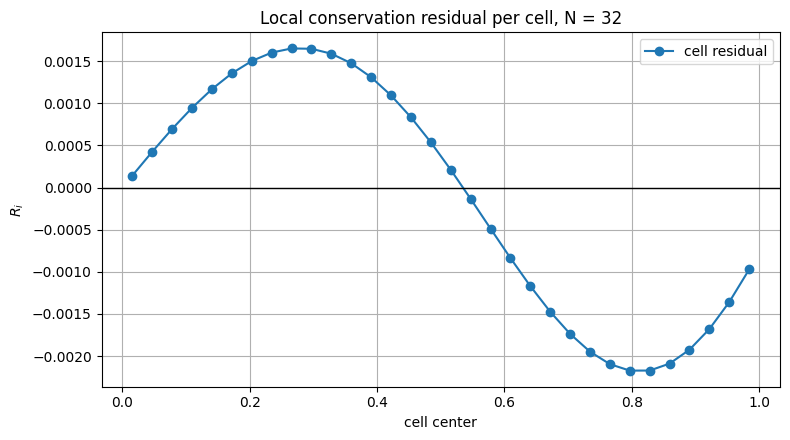

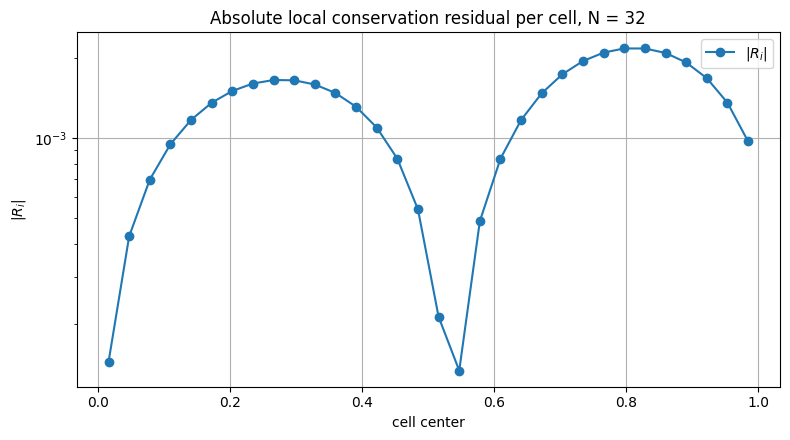

In [2]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import matplotlib.pyplot as plt

from dolfinx import fem, mesh
import ufl
import basix

def int_f_np(a, b):
    """
    Exact integral of f from a to b (works for scalars or arrays)
    """
    return 2.0 * np.pi * (
        (2.0 + a**2) * np.cos(2.0 * np.pi * a)
        - (2.0 + b**2) * np.cos(2.0 * np.pi * b)
    )


def compute_local_conservation_error(domain, ph, Kfun=None, ffun=None, qdeg=None):
    """
    Compute cellwise local conservation residuals on a 1D interval mesh:
        R_K = q_h(x_K^-) - q_h(x_K^+) - ∫_K f dx
    with q_h = -K(x) p_h'(x).

    This version works for scalar CG/Lagrange elements of degree 1, 2, 3, ...

    Parameters
    ----------
    domain : dolfinx.mesh.Mesh
    ph     : dolfinx.fem.Function
        Scalar FE solution on a 1D interval mesh.
    Kfun   : callable, optional
        Permeability function K(x). Must accept numpy arrays.
        Default: K(x) = 2 + x^2
    ffun   : callable, optional
        Source function f(x). Must accept numpy arrays.
        Default corresponds to the exact derivative of
            q(x) = 2*pi*(2+x^2)*cos(2*pi*x)
        i.e. f = -q'(x), consistent with
            q_right - q_left - ∫_K f dx
    qdeg   : int, optional
        Quadrature degree for ∫_K f dx. Default: 2*p + 4.

    Returns
    -------
    cell_centers : np.ndarray or None
    residuals    : np.ndarray or None
    abs_residuals: np.ndarray or None
        Returned on rank 0; on other ranks returns (None, None, None).

    Notes
    -----
    - Assumes a 1D interval mesh with affine cells.
    - Best suited for scalar Lagrange elements.
    - For interval Lagrange elements, orientation issues are benign.
    """
    if Kfun is None:
        Kfun = lambda x: 2.0 + x**2

    if ffun is None:
        # This is f = -d/dx[2*pi*(2+x^2)*cos(2*pi*x)]
        # = 2*pi * [ 2*(2+x^2)*pi*sin(2*pi*x) - 2*x*cos(2*pi*x) ]
        ffun = lambda x: (
            4.0 * math.pi**2 * (2.0 + x**2) * np.sin(2.0 * math.pi * x)
            - 4.0 * math.pi * x * np.cos(2.0 * math.pi * x)
        )

    V = ph.function_space
    comm = domain.comm
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    # Geometry connectivity
    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)

    # Local number of cells
    num_cells_local = domain.topology.index_map(tdim).size_local

    # FE metadata
    element = V.element
    degree = element.basix_element.degree
    basix_el = element.basix_element

    if qdeg is None:
        qdeg = 2 * degree + 4

    # Reference endpoints for interval [0, 1]
    end_pts = np.array([[0.0], [1.0]], dtype=np.float64)

    # Tabulate first derivatives of basis at the endpoints
    # tab shape ~ (nderivs, npoints, ndofs, value_size)
    tab = basix_el.tabulate(1, end_pts)
    dphi_dxi = tab[1, :, :, 0]   # shape: (2 endpoints, ndofs)

    # Quadrature on reference cell [0,1]
    qpts_ref, qw = basix.make_quadrature(basix.CellType.interval, qdeg)
    xiq = qpts_ref[:, 0]

    u = ph.x.array

    cell_centers_local = np.zeros(num_cells_local, dtype=np.float64)
    residuals_local = np.zeros(num_cells_local, dtype=np.float64)

    for cell in range(num_cells_local):
        # FE dofs on this cell
        cell_dofs = V.dofmap.cell_dofs(cell)
        u_cell = u[cell_dofs]

        # Physical cell endpoints from mesh vertices
        verts = c_to_v.links(cell)
        xv = domain.geometry.x[verts, 0]
        x0 = np.min(xv)
        x1 = np.max(xv)
        h = x1 - x0

        if h <= 0:
            raise ValueError(f"Non-positive cell length detected on cell {cell}.")

        # Evaluate p_h'(x) at left/right endpoint from the cell interior
        # dp/dx = dp/dxi * dxi/dx = (1/h) * dp/dxi
        dpdx_left = (dphi_dxi[0] @ u_cell) / h
        dpdx_right = (dphi_dxi[1] @ u_cell) / h

        # One-sided fluxes from inside this cell
        q_left = -Kfun(x0) * dpdx_left
        q_right = -Kfun(x1) * dpdx_right

        # Integrate source over physical cell via quadrature
        xq = x0 + h * xiq
        fvals = np.asarray(ffun(xq), dtype=np.float64)
        int_f = h * np.sum(qw * fvals)
        # int_f = int_f_np(x0, x1)

        residual = q_right - q_left - int_f

        cell_centers_local[cell] = 0.5 * (x0 + x1)
        residuals_local[cell] = residual

    gathered_centers = comm.gather(cell_centers_local, root=0)
    gathered_residuals = comm.gather(residuals_local, root=0)

    if comm.rank == 0:
        cell_centers = np.concatenate(gathered_centers)
        residuals = np.concatenate(gathered_residuals)

        idx = np.argsort(cell_centers)
        cell_centers = cell_centers[idx]
        residuals = residuals[idx]
        abs_residuals = np.abs(residuals)

        return cell_centers, residuals, abs_residuals

    return None, None, None


def plot_local_conservation_error(cell_centers, residuals, abs_residuals, N):
    plt.figure(figsize=(8, 4.5))
    plt.plot(cell_centers, residuals, "o-", label="cell residual")
    plt.axhline(0.0, color="k", linewidth=1)
    plt.xlabel("cell center")
    plt.ylabel(r"$R_i$")
    plt.title(f"Local conservation residual per cell, N = {N}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.semilogy(cell_centers, abs_residuals, "o-", label=r"$|R_i|$")
    plt.xlabel("cell center")
    plt.ylabel(r"$|R_i|$")
    plt.title(f"Absolute local conservation residual per cell, N = {N}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    N = 32

    # Make sure solve_darcy_1d uses the corrected source:
    # f = 4.0 - 2.0*x[0] + 6.0*x[0]**2
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    cell_centers, residuals, abs_residuals = compute_local_conservation_error(domain, ph)

    if MPI.COMM_WORLD.rank == 0:
        # print(f"{'cell center':>14} {'residual':>18} {'abs(residual)':>18}")
        # print("-" * 54)
        # for xc, r, ar in zip(cell_centers, residuals, abs_residuals):
        #     print(f"{xc:14.6e} {r:18.10e} {ar:18.10e}")

        print("\nMax abs local conservation error =", np.max(abs_residuals))
        plot_local_conservation_error(cell_centers, residuals, abs_residuals, N)

Epoch     0 | total_loss = 4.504477e-03 | pde_residual = 4.504477e-03 | ||r_θ|| = 0.000000e+00
Epoch   500 | total_loss = 1.447124e-04 | pde_residual = 4.483846e-05 | ||r_θ|| = 9.993697e-03
Epoch  1000 | total_loss = 1.071970e-04 | pde_residual = 4.417619e-06 | ||r_θ|| = 1.013802e-02
Epoch  1500 | total_loss = 1.063729e-04 | pde_residual = 3.457313e-06 | ||r_θ|| = 1.014473e-02
Epoch  2000 | total_loss = 1.061712e-04 | pde_residual = 3.228924e-06 | ||r_θ|| = 1.014605e-02
Epoch  2500 | total_loss = 1.060302e-04 | pde_residual = 3.073458e-06 | ||r_θ|| = 1.014676e-02
Epoch  3000 | total_loss = 1.059320e-04 | pde_residual = 2.967039e-06 | ||r_θ|| = 1.014717e-02
Epoch  3500 | total_loss = 1.058581e-04 | pde_residual = 2.884547e-06 | ||r_θ|| = 1.014759e-02
Epoch  4000 | total_loss = 1.058352e-04 | pde_residual = 2.848651e-06 | ||r_θ|| = 1.014823e-02
Epoch  4500 | total_loss = 1.058196e-04 | pde_residual = 3.083471e-06 | ||r_θ|| = 1.013588e-02
Epoch  5000 | total_loss = 1.057301e-04 | pde_resi

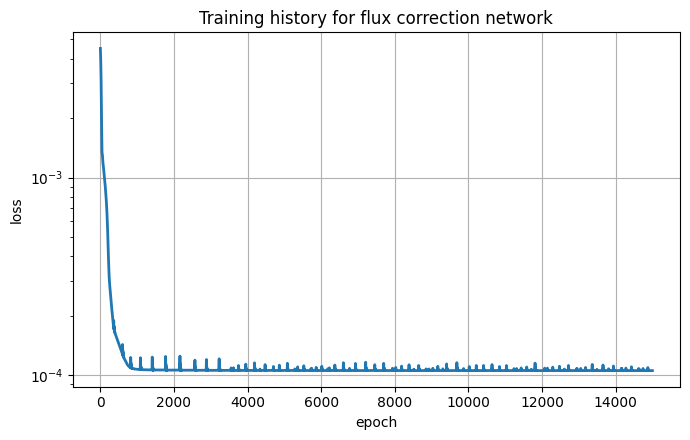

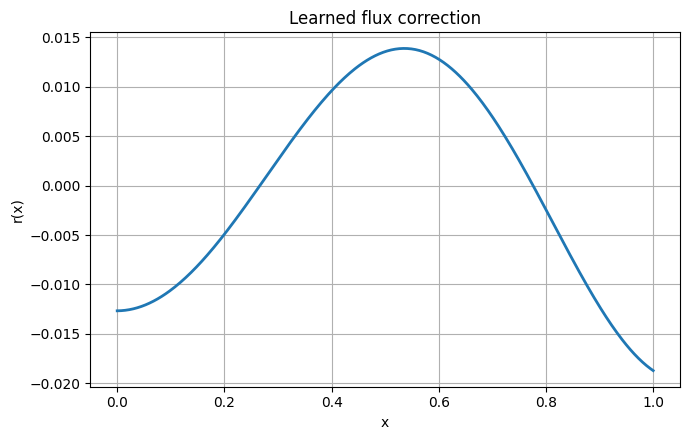

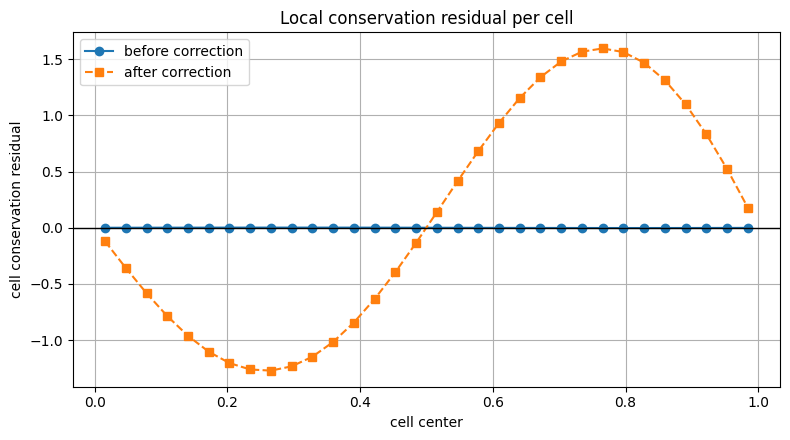

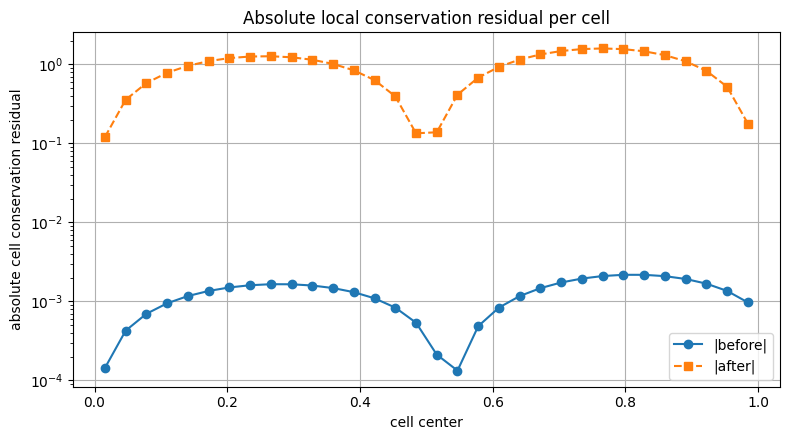

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim


# ------------------------------------------------------------
# Utilities for cellwise data from the FE solution
# ------------------------------------------------------------
import numpy as np
import basix


import numpy as np
import basix


def extract_cell_data_1d(domain, ph):
    """
    For each local cell on a 1D interval mesh, extract:
      - x_left, x_right, x_center
      - p_h'(x) at left, center, right
      - p_h''(x) at left, center, right

    Gather everything on rank 0.

    Returns
    -------
    x_left, x_right, x_center,
    dpdx_left, dpdx_center, dpdx_right,
    d2pdx2_left, d2pdx2_center, d2pdx2_right

    On rank 0: numpy arrays sorted by x_center
    On other ranks: None, ..., None
    """
    comm = domain.comm
    V = ph.function_space
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)

    u = ph.x.array
    num_cells_local = domain.topology.index_map(tdim).size_local

    x_left_local = np.zeros(num_cells_local, dtype=np.float64)
    x_right_local = np.zeros(num_cells_local, dtype=np.float64)
    x_center_local = np.zeros(num_cells_local, dtype=np.float64)

    dpdx_left_local = np.zeros(num_cells_local, dtype=np.float64)
    dpdx_center_local = np.zeros(num_cells_local, dtype=np.float64)
    dpdx_right_local = np.zeros(num_cells_local, dtype=np.float64)

    d2pdx2_left_local = np.zeros(num_cells_local, dtype=np.float64)
    d2pdx2_center_local = np.zeros(num_cells_local, dtype=np.float64)
    d2pdx2_right_local = np.zeros(num_cells_local, dtype=np.float64)

    basix_el = V.element.basix_element

    # Reference points on [0,1]: left, center, right
    ref_pts = np.array([[0.0], [0.5], [1.0]], dtype=np.float64)

    # Tabulate up to second derivatives
    # tab shape: (nderivs, npoints, ndofs, value_size)
    tab = basix_el.tabulate(2, ref_pts)

    dphi_dxi = tab[1, :, :, 0]      # shape (3, ndofs)
    d2phi_dxi2 = tab[2, :, :, 0]    # shape (3, ndofs)

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)
        u_cell = u[cell_dofs]

        verts = c_to_v.links(cell)
        xv = domain.geometry.x[verts, 0]

        x0 = np.min(xv)
        x1 = np.max(xv)
        h = x1 - x0

        if h <= 0:
            raise ValueError(f"Non-positive cell length detected on cell {cell}.")

        # Chain rule from reference interval [0,1] to physical cell [x0,x1]
        # x = x0 + h * xi
        # d/dx = (1/h) d/dxi
        # d2/dx2 = (1/h^2) d2/dxi2
        dpdx_left = (dphi_dxi[0] @ u_cell) / h
        dpdx_center = (dphi_dxi[1] @ u_cell) / h
        dpdx_right = (dphi_dxi[2] @ u_cell) / h

        d2pdx2_left = (d2phi_dxi2[0] @ u_cell) / (h**2)
        d2pdx2_center = (d2phi_dxi2[1] @ u_cell) / (h**2)
        d2pdx2_right = (d2phi_dxi2[2] @ u_cell) / (h**2)

        x_left_local[cell] = x0
        x_right_local[cell] = x1
        x_center_local[cell] = 0.5 * (x0 + x1)

        dpdx_left_local[cell] = dpdx_left
        dpdx_center_local[cell] = dpdx_center
        dpdx_right_local[cell] = dpdx_right

        d2pdx2_left_local[cell] = d2pdx2_left
        d2pdx2_center_local[cell] = d2pdx2_center
        d2pdx2_right_local[cell] = d2pdx2_right

    gathered_left = comm.gather(x_left_local, root=0)
    gathered_right = comm.gather(x_right_local, root=0)
    gathered_center = comm.gather(x_center_local, root=0)

    gathered_dpdx_left = comm.gather(dpdx_left_local, root=0)
    gathered_dpdx_center = comm.gather(dpdx_center_local, root=0)
    gathered_dpdx_right = comm.gather(dpdx_right_local, root=0)

    gathered_d2pdx2_left = comm.gather(d2pdx2_left_local, root=0)
    gathered_d2pdx2_center = comm.gather(d2pdx2_center_local, root=0)
    gathered_d2pdx2_right = comm.gather(d2pdx2_right_local, root=0)

    if comm.rank == 0:
        x_left = np.concatenate(gathered_left)
        x_right = np.concatenate(gathered_right)
        x_center = np.concatenate(gathered_center)

        dpdx_left = np.concatenate(gathered_dpdx_left)
        dpdx_center = np.concatenate(gathered_dpdx_center)
        dpdx_right = np.concatenate(gathered_dpdx_right)

        d2pdx2_left = np.concatenate(gathered_d2pdx2_left)
        d2pdx2_center = np.concatenate(gathered_d2pdx2_center)
        d2pdx2_right = np.concatenate(gathered_d2pdx2_right)

        idx = np.argsort(x_center)

        return (
            x_left[idx],
            x_right[idx],
            x_center[idx],
            dpdx_left[idx],
            dpdx_center[idx],
            dpdx_right[idx],
            d2pdx2_left[idx],
            d2pdx2_center[idx],
            d2pdx2_right[idx],
        )

    return None, None, None, None, None, None, None, None, None


# ------------------------------------------------------------
# Problem-specific coefficient and source
# ------------------------------------------------------------
def K_fun_np(x):
    return 2.0 + x**2


def dKdx_fun_np(x):
    return 2.0 * x


import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


def f_fun_np(x):
    """
    Exact source:
        f(x) = 4*pi^2*(2+x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x)
    Works for scalar x or numpy array x.
    """
    return (
        4.0 * math.pi**2 * (2.0 + x**2) * np.sin(2.0 * math.pi * x)
        - 4.0 * math.pi * x * np.cos(2.0 * math.pi * x)
    )


# ------------------------------------------------------------
# Small scalar neural network for flux correction r(x)
# ------------------------------------------------------------
class FluxCorrectionNet(nn.Module):
    def __init__(self, width=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

        # Start from zero correction
        last_layer = self.net[-1]
        nn.init.zeros_(last_layer.weight)
        nn.init.zeros_(last_layer.bias)

    def forward(self, x):
        return self.net(x)


# ------------------------------------------------------------
# Train r so that q_h = -K p_h' + r satisfies q_h' = f
# at element centers
# ------------------------------------------------------------
def train_flux_correction(
    x_center,
    dpdx_center,
    d2pdx2_center,
    epochs=5000,
    lr=1e-3,
    reg_lambda=1e-2,
    verbose_every=500,
):
    """
    Train scalar NN r(x) so that the corrected flux

        q_h(x) = -K(x) p_h'(x) + r(x)

    satisfies the conservation law

        q_h'(x) = f(x)

    at cell centers x_c.

    This version is valid for P1, P2, and higher.

    Since
        q_h'(x) = d/dx[-K(x)p_h'(x) + r(x)]
                = -K'(x)p_h'(x) - K(x)p_h''(x) + r'(x),

    the pointwise residual enforced at cell centers is

        -K'(x_c) p_h'(x_c) - K(x_c) p_h''(x_c) + r'(x_c) - f(x_c).

    Parameters
    ----------
    x_center : np.ndarray
        Cell-center coordinates, shape (N,)
    dpdx_center : np.ndarray
        Approximation of p_h'(x_c), shape (N,)
    d2pdx2_center : np.ndarray
        Approximation of p_h''(x_c), shape (N,)
        For P1, this should just be zeros.
    epochs : int
    lr : float
    reg_lambda : float
        L2 penalty on r(x)
    verbose_every : int

    Returns
    -------
    model : torch.nn.Module
    loss_history : list[float]
    """
    device = torch.device("cpu")

    xc = torch.tensor(
        x_center.reshape(-1, 1),
        dtype=torch.float64,
        device=device,
        requires_grad=True,
    )

    dp = torch.tensor(
        dpdx_center.reshape(-1, 1),
        dtype=torch.float64,
        device=device,
    )

    d2p = torch.tensor(
        d2pdx2_center.reshape(-1, 1),
        dtype=torch.float64,
        device=device,
    )

    model = FluxCorrectionNet(width=16).to(device).double()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Neural correction r(x)
        r = model(xc)

        # r'(x)
        drdx = torch.autograd.grad(
            outputs=r,
            inputs=xc,
            grad_outputs=torch.ones_like(r),
            create_graph=True,
        )[0]

        # K(x) = 2 + x^2, so K'(x) = 2x
        Kval = 2.0 + xc**2
        Kprime = 2.0 * xc

        # Exact source f(x)
        fval = (
            4.0 * math.pi**2 * (2.0 + xc**2) * torch.sin(2.0 * math.pi * xc)
            - 4.0 * math.pi * xc * torch.cos(2.0 * math.pi * xc)
        )

        # Residual for q_h' = f, where q_h = -K p_h' + r
        residual = -Kprime * dp - Kval * d2p + drdx - fval

        loss_pde = torch.mean(residual**2)
        loss_reg = torch.mean(r**2)
        loss = loss_pde + reg_lambda * loss_reg

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:5d} | "
                f"total_loss = {loss.item():.6e} | "
                f"pde_residual = {loss_pde.item():.6e} | "
                f"||r_θ|| = {math.sqrt(loss_reg.item()):.6e}"
            )

    return model, loss_history


# ------------------------------------------------------------
# Compute local conservation after correction
# ------------------------------------------------------------
def compute_local_conservation_after_correction(domain, ph, model):
    """
    Compute cellwise corrected local conservation residual:

        R_i^corr = F_corr(x_R) - F_corr(x_L) - ∫_K f dx

    where
        F_corr(x) = K(x) p_h'(cell) + r(x)

    on each cell.
    """
    comm = domain.comm
    rank = comm.rank

    x_left, x_right, x_center, dpdx_l, dpdx_r, dpdx_c, dp2dx2_l, dp2dx2_r, dp2dx2_c  = extract_cell_data_1d(domain, ph)

    if rank != 0:
        return None, None, None, None

    model.eval()

    with torch.no_grad():
        xL_t = torch.tensor(x_left.reshape(-1, 1), dtype=torch.float64)
        xR_t = torch.tensor(x_right.reshape(-1, 1), dtype=torch.float64)

        rL = model(xL_t).cpu().numpy().flatten()
        rR = model(xR_t).cpu().numpy().flatten()

    F_left = -K_fun_np(x_left) * dpdx_l + rL
    F_right = -K_fun_np(x_right) * dpdx_r + rR

    cell_integrals = int_f_np(x_left, x_right)

    residuals = F_right - F_left - cell_integrals
    abs_residuals = np.abs(residuals)

    return x_center, residuals, abs_residuals, {
        "F_left": F_left,
        "F_right": F_right,
        "r_left": rL,
        "r_right": rR,
    }


# ------------------------------------------------------------
# Compare before/after correction
# ------------------------------------------------------------
def compute_local_conservation_before_correction(domain, ph):
    """
    Raw local conservation residual using
        F_raw = -K(x) p_h'(x)
    evaluated at the left/right endpoints of each cell.

    Works for P1, P2, and higher on a 1D interval mesh.
    """
    comm = domain.comm

    (
        x_left,
        x_right,
        x_center,
        dpdx_left,
        dpdx_center,
        dpdx_right,
        d2pdx2_left,
        d2pdx2_center,
        d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    if comm.rank != 0:
        return None, None, None

    F_left = -K_fun_np(x_left) * dpdx_left
    F_right = -K_fun_np(x_right) * dpdx_right
    cell_integrals = int_f_np(x_left, x_right)

    residuals = F_right - F_left - cell_integrals
    abs_residuals = np.abs(residuals)

    return x_center, residuals, abs_residuals


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def plot_training_history(loss_history):
    plt.figure(figsize=(7, 4.5))
    plt.semilogy(loss_history, linewidth=2)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training history for flux correction network")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_corrected_local_conservation(x_center, residual_before, residual_after):
    plt.figure(figsize=(8, 4.5))
    plt.plot(x_center, residual_before, "o-", label="before correction")
    plt.plot(x_center, residual_after, "s--", label="after correction")
    plt.axhline(0.0, color="k", linewidth=1)
    plt.xlabel("cell center")
    plt.ylabel("cell conservation residual")
    plt.title("Local conservation residual per cell")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.semilogy(x_center, np.abs(residual_before), "o-", label="|before|")
    plt.semilogy(x_center, np.abs(residual_after), "s--", label="|after|")
    plt.xlabel("cell center")
    plt.ylabel("absolute cell conservation residual")
    plt.title("Absolute local conservation residual per cell")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_flux_correction(model):
    x_plot = np.linspace(0.0, 1.0, 400)
    with torch.no_grad():
        xt = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float64)
        r_plot = model(xt).cpu().numpy().flatten()

    plt.figure(figsize=(7, 4.5))
    plt.plot(x_plot, r_plot, linewidth=2)
    plt.xlabel("x")
    plt.ylabel("r(x)")
    plt.title("Learned flux correction")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main experiment: N = 32
# ------------------------------------------------------------
if __name__ == "__main__":
    N = 32

    # solve FE problem
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    # raw local conservation
    x_center_before, residual_before, abs_before = compute_local_conservation_before_correction(domain, ph)

    # training data from FE solution
    (
        x_left,
        x_right,
        x_center,
        dpdx_left,
        dpdx_center,
        dpdx_right,
        d2pdx2_left,
        d2pdx2_center,
        d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    if MPI.COMM_WORLD.rank == 0:
        # train NN correction on element centers
        model, loss_history = train_flux_correction(
            x_center=x_center,
            dpdx_center=dpdx_center,
            d2pdx2_center=d2pdx2_center,
            epochs=15000,
            lr=1e-3,
            reg_lambda=1e0,
            verbose_every=500,
        )

        # corrected local conservation
        x_center_after, residual_after, abs_after, extra = compute_local_conservation_after_correction(domain, ph, model)

        print("\nCellwise local conservation error:")
        print(f"{'center':>12} {'before':>18} {'after':>18}")
        print("-" * 52)
        for xc, rb, ra in zip(x_center_after, residual_before, residual_after):
            print(f"{xc:12.6f} {rb:18.10e} {ra:18.10e}")

        print("\nSummary:")
        print(f"max |residual before| = {np.max(abs_before):.10e}")
        print(f"max |residual after|  = {np.max(abs_after):.10e}")
        print(f"L2  |residual before| = {np.sqrt(np.sum(abs_before**2)):.10e}")
        print(f"L2  |residual after|  = {np.sqrt(np.sum(abs_after**2)):.10e}")

        plot_training_history(loss_history)
        plot_flux_correction(model)
        plot_corrected_local_conservation(x_center_after, residual_before, residual_after)

In [4]:
residual_before, residual_after

(array([ 0.00014357,  0.00042655,  0.00069711,  0.00094728,  0.00116949,
         0.00135679,  0.00150297,  0.00160281,  0.00165218,  0.00164825,
         0.00158958,  0.0014763 ,  0.00131019,  0.00109471,  0.00083503,
         0.000538  ,  0.00021203, -0.00013304, -0.00048623, -0.00083565,
        -0.00116886, -0.00147331, -0.00173672, -0.00194761, -0.00209574,
        -0.00217255, -0.00217169, -0.00208929, -0.00192437, -0.00167902,
        -0.00135849, -0.00097125]),
 array([-0.12050998, -0.35744255, -0.58186545, -0.78570587, -0.96152794,
        -1.10277308, -1.20397896, -1.26097053, -1.27101771, -1.23295402,
        -1.14725153, -1.01604794, -0.8431228 , -0.63382086, -0.39492205,
        -0.13445933,  0.13851295,  0.41419538,  0.68235788,  0.93268388,
         1.15513421,  1.34031924,  1.47986656,  1.56677095,  1.59571281,
         1.56333147,  1.46844071,  1.31217467,  1.09805464,  0.83196927,
         0.52206382,  0.17853716]))

In [ ]:
def q_exact_np(x):
    """
    Exact Darcy flux for
        p_exact(x) = sin(2*pi*x),
        K(x) = 2 + x^2

    q_exact(x) = -K(x) p_exact'(x)
               = -(2+x^2) * 2*pi*cos(2*pi*x)
    """
    return -(2.0 + x**2) * (2.0 * np.pi * np.cos(2.0 * np.pi * x))


def compute_flux_L2_error_before_after(domain, ph, model, quad_degree=8):
    """
    Compute L2 flux error before and after correction:
        q_raw  = -K p_h'
        q_corr = -K p_h' + r(x)

    compared with exact flux
        q_exact = -(2+x^2) * 2*pi*cos(2*pi*x)

    Works for P1, P2, and higher on a 1D interval mesh.

    Returns on rank 0:
        err_raw, err_corr
    """
    comm = domain.comm
    rank = comm.rank
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    V = ph.function_space
    uh = ph.x.array

    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)
    num_cells_local = domain.topology.index_map(tdim).size_local

    basix_el = V.element.basix_element

    # Quadrature on reference interval [0,1]
    qpts_ref, qw = basix.make_quadrature(basix.CellType.interval, quad_degree)
    xiq = qpts_ref[:, 0]

    # Tabulate first derivatives of basis at quadrature points
    # tab shape: (nderivs, npoints, ndofs, value_size)
    tab = basix_el.tabulate(1, qpts_ref)
    dphi_dxi = tab[1, :, :, 0]   # shape (nq, ndofs)

    err_raw_sq_local = 0.0
    err_corr_sq_local = 0.0

    model.eval()

    with torch.no_grad():
        for cell in range(num_cells_local):
            cell_dofs = V.dofmap.cell_dofs(cell)
            u_cell = uh[cell_dofs]

            verts = c_to_v.links(cell)
            xv = domain.geometry.x[verts, 0]
            a = np.min(xv)
            b = np.max(xv)
            h = b - a

            if h <= 0:
                raise ValueError(f"Non-positive cell length detected on cell {cell}.")

            # Map quadrature points from reference [0,1] to physical cell [a,b]
            xq = a + h * xiq

            # Evaluate p_h'(xq)
            # dp/dx = (1/h) * dp/dxi
            dpdx_q = (dphi_dxi @ u_cell) / h   # shape (nq,)

            # Raw flux
            q_raw = -(2.0 + xq**2) * dpdx_q

            # Neural correction r(xq)
            xq_t = torch.tensor(xq.reshape(-1, 1), dtype=torch.float64)
            rq = model(xq_t).cpu().numpy().reshape(-1)

            # Corrected flux
            q_corr = q_raw + rq

            # Exact flux
            q_ex = -(2.0 + xq**2) * 2.0 * math.pi * np.cos(2.0 * math.pi * xq)

            # Physical integral: ∫_K ... dx = h ∫_[0,1] ... dxi
            err_raw_sq_local += h * np.sum(qw * (q_raw - q_ex) ** 2)
            err_corr_sq_local += h * np.sum(qw * (q_corr - q_ex) ** 2)

    err_raw_sq = comm.reduce(err_raw_sq_local, op=MPI.SUM, root=0)
    err_corr_sq = comm.reduce(err_corr_sq_local, op=MPI.SUM, root=0)

    if rank != 0:
        return None, None

    return np.sqrt(err_raw_sq), np.sqrt(err_corr_sq)


if MPI.COMM_WORLD.rank == 0:
    err_flux_raw, err_flux_corr = compute_flux_L2_error_before_after(domain, ph, model)

    print("\nFlux L2 error compared with exact flux q = -K p_exact':")
    print(f"||q_raw  - q_exact||_L2  = {err_flux_raw:.10e}")
    print(f"||q_corr - q_exact||_L2  = {err_flux_corr:.10e}")


Flux L2 error compared with exact flux q = -K p_exact':
||q_raw  - q_exact||_L2  = 1.5108690954e-02
||q_corr - q_exact||_L2  = 1.0511572248e+01


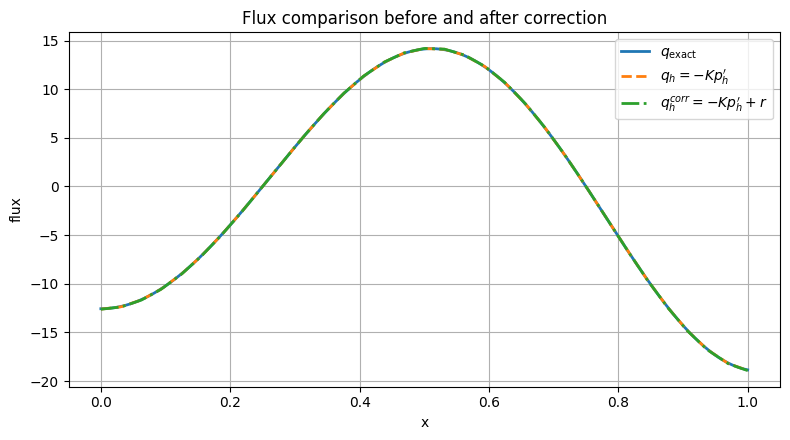

In [6]:
def plot_flux_comparison(domain, ph, model, nplot=400):
    comm = domain.comm
    rank = comm.rank
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    (
        x_left,
        x_right,
        x_center,
        _dpdx_left,
        _dpdx_center,
        _dpdx_right,
        _d2pdx2_left,
        _d2pdx2_center,
        _d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    if rank != 0:
        return

    V = ph.function_space
    uh = ph.x.array
    basix_el = V.element.basix_element

    x_plot = np.linspace(0.0, 1.0, nplot)
    q_raw_plot = np.zeros_like(x_plot)

    for i, x in enumerate(x_plot):
        cell = np.searchsorted(x_right, x, side="right")
        if cell >= len(x_right):
            cell = len(x_right) - 1

        a = x_left[cell]
        b = x_right[cell]
        h = b - a

        if x >= b and cell == len(x_right) - 1:
            xi = 1.0
        else:
            xi = (x - a) / h

        ref_pt = np.array([[xi]], dtype=np.float64)
        tab = basix_el.tabulate(1, ref_pt)

        dphi_dxi = tab[1, 0, :, 0]

        cell_dofs = V.dofmap.cell_dofs(cell)
        u_cell = uh[cell_dofs]

        dpdx = (dphi_dxi @ u_cell) / h
        q_raw_plot[i] = -(2.0 + x**2) * dpdx

    # Evaluate correction model
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float64)
        r_plot = model(xt).cpu().numpy().flatten()

    q_corr_plot = q_raw_plot + r_plot
    q_ex_plot = q_exact_np(x_plot)

    # Plot
    plt.figure(figsize=(8, 4.5))

    plt.plot(x_plot, q_ex_plot, label=r"$q_{\mathrm{exact}}$", linewidth=2)
    plt.plot(x_plot, q_raw_plot, "--", label=r"$q_h = -K p_h'$", linewidth=2)
    plt.plot(x_plot, q_corr_plot, "-.", label=r"$q_h^{corr} = -K p_h' + r$", linewidth=2)

    plt.xlabel("x")
    plt.ylabel("flux")
    plt.title("Flux comparison before and after correction")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_flux_comparison(domain, ph, model)

In [7]:
def print_flux_jumps(domain, ph):
    comm = domain.comm
    rank = comm.rank
    if rank != 0:
        return

    (
        x_left,
        x_right,
        x_center,
        _dpdx_left,
        _dpdx_center,
        _dpdx_right,
        _d2pdx2_left,
        _d2pdx2_center,
        _d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    V = ph.function_space
    uh = ph.x.array
    basix_el = V.element.basix_element

    print("\nInterior flux jumps:")
    print(" i        x_i                 q^-                   q^+                jump=q^+-q^-")
    print("-"*95)

    for i in range(len(x_right) - 1):
        x_int = x_right[i]

        # left trace from cell i at xi=1
        aL = x_left[i]
        bL = x_right[i]
        hL = bL - aL
        refL = np.array([[1.0]], dtype=np.float64)
        tabL = basix_el.tabulate(1, refL)
        dphiL = tabL[1, 0, :, 0]
        dofsL = V.dofmap.cell_dofs(i)
        uL = uh[dofsL]
        dpdxL = (dphiL @ uL) / hL
        qL = -(2.0 + x_int**2) * dpdxL

        # right trace from cell i+1 at xi=0
        aR = x_left[i + 1]
        bR = x_right[i + 1]
        hR = bR - aR
        refR = np.array([[0.0]], dtype=np.float64)
        tabR = basix_el.tabulate(1, refR)
        dphiR = tabR[1, 0, :, 0]
        dofsR = V.dofmap.cell_dofs(i + 1)
        uR = uh[dofsR]
        dpdxR = (dphiR @ uR) / hR
        qR = -(2.0 + x_int**2) * dpdxR

        jump = qR - qL
        print(f"{i:2d}   {x_int: .12e}   {qL: .12e}   {qR: .12e}   {jump: .12e}")

print_flux_jumps(domain,ph)


Interior flux jumps:
 i        x_i                 q^-                   q^+                jump=q^+-q^-
-----------------------------------------------------------------------------------------------
 0    3.125000000000e-02   -1.237100631455e+01   -1.236978601580e+01    1.220298752679e-03
 1    6.250000000000e-02   -1.167091814339e+01   -1.166851969987e+01    2.398443517075e-03
 2    9.375000000000e-02   -1.052980636777e+01   -1.052631283328e+01    3.493534490792e-03
 3    1.250000000000e-01   -8.986079666111e+00   -8.981612512956e+00    4.467153154341e-03
 4    1.562500000000e-01   -7.091981952754e+00   -7.086697417604e+00    5.284535149400e-03
 5    1.875000000000e-01   -4.912089794962e+00   -4.906174133182e+00    5.915661779937e-03
 6    2.187500000000e-01   -2.521430334886e+00   -2.515094091823e+00    6.336243063190e-03
 7    2.500000000000e-01   -3.258090396722e-03    3.270475209084e-03    6.528565605806e-03
 8    2.812500000000e-01    2.553461745100e+00    2.559943924451e+00  